# Emotion Classification from Text

## Introduction
The goal of this project is to train and compare different machine learning models to classify short text messages according to the main emotion they express. The emotions include joy, sadness, fear, anger, love, and surprise. Three different types of models are explored: a fully connected neural network, a recurrent neural network, and a transformer-based model.


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [ ]:
from datasets import Dataset
import evaluate

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Dataset Description

The dataset consists of short text samples labeled with one of several emotion categories. The data is split into training and test sets. The validation set is provided separately at the end of the project to evaluate the final model and ensure there is no overfitting on the test data.


In [ ]:
#read 5 lines of train dataset
df_train=pd.read_csv("/content/drive/MyDrive/dataset/train.txt")
print(df_train.head())



                     i didnt feel humiliated;sadness
0  i can go from feeling so hopeless to so damned...
1  im grabbing a minute to post i feel greedy wro...
2  i am ever feeling nostalgic about the fireplac...
3                         i am feeling grouchy;anger
4  ive been feeling a little burdened lately wasn...


In [ ]:
df_train.describe()

,i didnt feel humiliated;sadness
count,15999
unique,15998
top,i feel more adventurous willing to take risks ...
freq,2


In [ ]:
df_train.shape

(15999, 1)

In [ ]:
#read 5 lines of test dataset
df_test=pd.read_csv("/content/drive/MyDrive/dataset/test.txt")
print(df_test.head())

  im feeling rather rotten so im not very ambitious right now;sadness
0  im updating my blog because i feel shitty;sadness                 
1  i never make her separate from me because i do...                 
2  i left with my bouquet of red and yellow tulip...                 
3  i was feeling a little vain when i did this on...                 
4  i cant walk into a shop anywhere where i do no...                 


In [ ]:
df_test.describe()


,im feeling rather rotten so im not very ambitious right now;sadness
count,1999
unique,1999
top,i feel all weird when i have to meet w people ...
freq,1


In [ ]:
df_test.shape

(1999, 1)

In [ ]:
#divide the dataset into label
df_train_by_label = df_train.groupby(df_train.iloc[:, 0].str.split(';').str[-1])



In [ ]:
grouped_dict = {name: group for name, group in df_train_by_label}
for label, df in grouped_dict.items():
    print(f"Label '{label}': {df.shape}")

Label 'anger': (2159, 1)
Label 'fear': (1937, 1)
Label 'joy': (5362, 1)
Label 'love': (1304, 1)
Label 'sadness': (4665, 1)
Label 'surprise': (572, 1)


### Label Distribution

Before training the models, the distribution of emotion labels is examined to understand potential class imbalance.


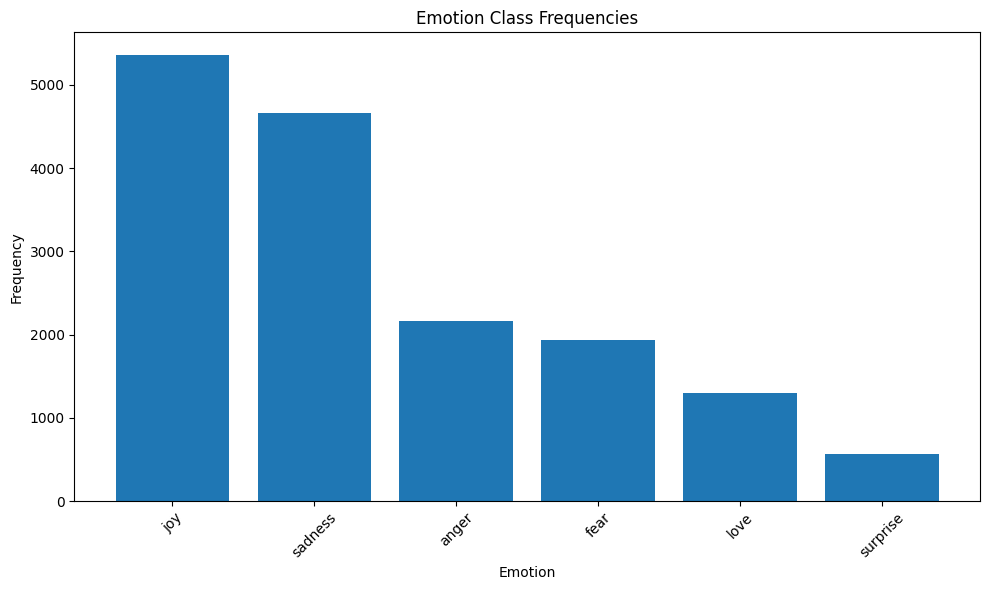

In [ ]:
#plot train data

# Extract label from the combined column (text;label format)
df_train_copy = df_train.copy()
df_train_copy['label'] = df_train_copy.iloc[:, 0].str.split(';').str[-1]

counts = df_train_copy['label'].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.title('Emotion Class Frequencies')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Here joy and sadness contribute to 60% of the total data and surprise is under 4%. This can lead to model overfit in the majortiy classes.

In [ ]:
def load_data(path):
    texts = []
    labels = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            text, label = line.rsplit(";", 1)
            texts.append(text.strip())
            labels.append(label.strip())
    return texts, labels

X_train, y_train = load_data("/content/drive/MyDrive/dataset//train.txt")
X_test, y_test = load_data("/content/drive/MyDrive/dataset//test.txt")

In [ ]:
from collections import Counter
Counter(y_train)


Counter({'sadness': 4666,
         'anger': 2159,
         'love': 1304,
         'surprise': 572,
         'fear': 1937,
         'joy': 5362})

## Text Preprocessing

Basic text preprocessing is applied to reduce noise while preserving emotional content. This includes lowercasing and removing URLs and non-alphabetic characters.


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return text

X_train_clean = [clean_text(t) for t in X_train]
X_test_clean = [clean_text(t) for t in X_test]


## Model 1: Fully Connected Neural Network

The first approach uses a fully connected neural network trained on TF-IDF representations of the text. This model serves as a baseline and does not capture word order or contextual information.


In [ ]:
#Fully Connected Neural Network
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train_clean)
X_test_vec = vectorizer.transform(X_test_clean)




In [ ]:
#neural network model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model_ffnn = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_vec.shape[1],)),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dense(len(set(y_train)), activation="softmax")
])




/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

model_ffnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,926 (9.90 MB)

 Trainable params: 2,593,926 (9.90 MB)

 Non-trainable params: 0 (0.00 B)

We compile the model, choosing relevant loss function, optimizer and metrics

In [ ]:
model_ffnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

We train the model on the dataset

In [ ]:
#encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [ ]:
#Train the model
history= model_ffnn.fit(
    X_train_vec.toarray(),
    y_train_enc,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4309 - loss: 1.4713 - val_accuracy: 0.8475 - val_loss: 0.5312
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8991 - loss: 0.3403 - val_accuracy: 0.8750 - val_loss: 0.3443
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9625 - loss: 0.1177 - val_accuracy: 0.8775 - val_loss: 0.3537
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9803 - loss: 0.0646 - val_accuracy: 0.8737 - val_loss: 0.4087
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9885 - loss: 0.0395 - val_accuracy: 0.8619 - val_loss: 0.4341
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9936 - loss: 0.0257 - val_accuracy: 0.8669 - val_loss: 0.4592
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9945 - loss: 0.0211 - val_accuracy: 0.8506 - val_loss: 0.5191
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9952 - loss: 0.0168 - val_accuracy: 0.

The fully connected neural network serves as a baseline. While it performs reasonably well on frequent emotions such as joy and sadness, it struggles with subtle distinctions like fear versus surprise due to the loss of word order information.

In [ ]:
def plot_results(history):
    hist_df = pd.DataFrame(history.history)
    hist_df.index = np.arange(1, len(hist_df) + 1)

    fig, axs = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

    axs[0].plot(hist_df["accuracy"], label="Training Accuracy", lw=3)
    axs[0].plot(hist_df["val_accuracy"], label="Validation Accuracy", lw=3)
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(hist_df["loss"], label="Training Loss", lw=3)
    axs[1].plot(hist_df["val_loss"], label="Validation Loss", lw=3)
    axs[1].set_ylabel("Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].legend()
    axs[1].grid()

    plt.show()


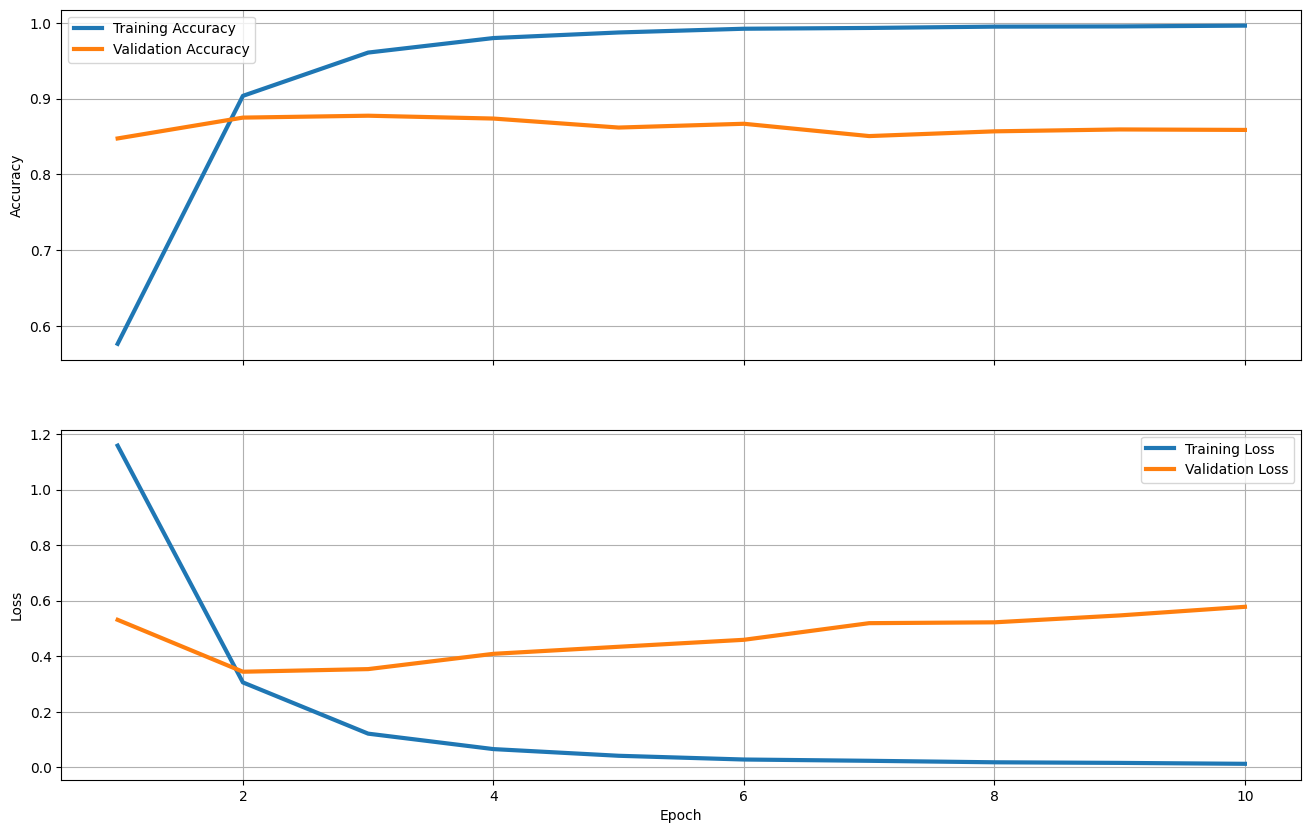

In [ ]:
plot_results(history)


The training accuracy keeps increasing and almost reaches 100%, while the validation accuracy stops improving after the first few epochs. At the same time, the validation loss starts to increase, even though the training loss keeps decreasing. This shows that the model begins to overfit after a few epochs, so stopping early gives better generalization. This means the model is overfitting and not generalizing well. This happens because TF-IDF does not capture context in the text.

In [ ]:
# use encoded numeric labels and the TF-IDF test vectors for prediction
y_true = y_test_enc
y_probs = model_ffnn.predict(X_test_vec)
y_pred = np.argmax(y_probs, axis=1)
labels = le.classes_
labels

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step


array(['anger', 'fear', 'joy', 'love', 'sadness', 'surprise'], dtype='<U8')

In [ ]:
report = classification_report(y_true=y_true, y_pred=y_pred, target_names=labels, digits=4)
print(report)

              precision    recall  f1-score   support

       anger     0.8599    0.8036    0.8308       275
        fear     0.8133    0.8170    0.8151       224
         joy     0.8771    0.9137    0.8950       695
        love     0.7847    0.7107    0.7459       159
     sadness     0.8765    0.9036    0.8898       581
    surprise     0.7843    0.6061    0.6838        66

    accuracy                         0.8585      2000
   macro avg     0.8326    0.7924    0.8101      2000
weighted avg     0.8570    0.8585    0.8569      2000



63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


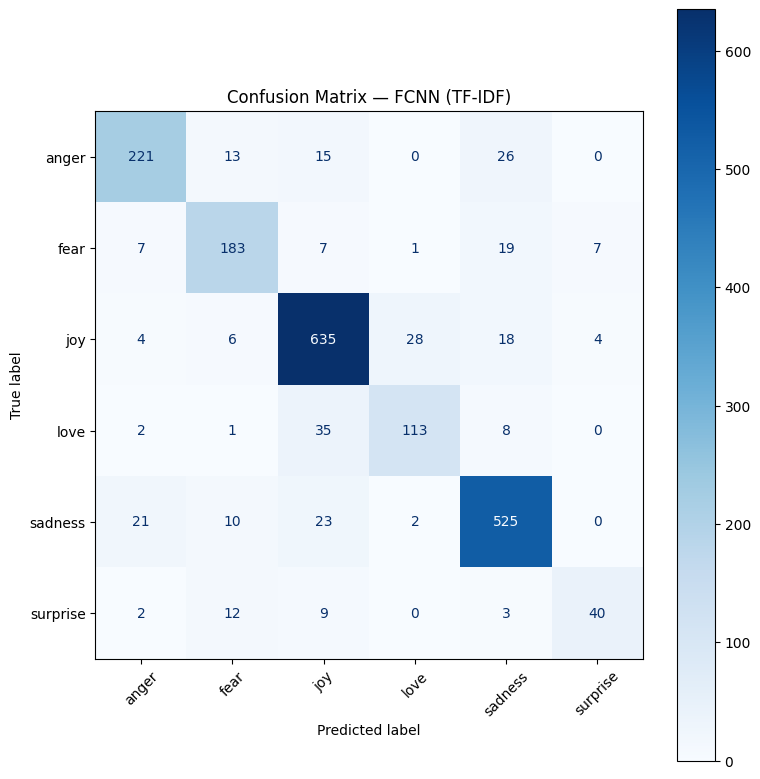

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict
y_probs = model_ffnn.predict(X_test_vec.toarray())
y_pred = np.argmax(y_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Confusion Matrix — FCNN (TF-IDF)")
plt.tight_layout()
plt.show()


The Fully Connected Neural Network trained on TF-IDF features provides a strong baseline for emotion classification. The confusion matrix shows that the model performs well on emotions with explicit lexical cues such as joy and sadness.
However, it struggles with semantically overlapping emotions like love vs joy and fear vs sadness, as well as context-dependent emotions such as surprise.
This highlights the limitation of bag-of-words representations, which motivates the use of sequential models and transformer-based architectures.

## Model 2: Recurrent Neural Network (LSTM)

To better capture sequential information in text, a recurrent neural network based on an LSTM architecture is used. Unlike the fully connected model, the LSTM processes the text as a sequence of words, allowing it to model temporal and contextual dependencies.

This approach is expected to perform better on emotions that depend on the flow and structure of a sentence.


In [ ]:
#tokenisation + padding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(X_train_clean)

X_train_seq = tokenizer.texts_to_sequences(X_train_clean)
X_test_seq = tokenizer.texts_to_sequences(X_test_clean)

X_train_pad = pad_sequences(X_train_seq, maxlen=100)
X_test_pad = pad_sequences(X_test_seq, maxlen=100)


In [ ]:
#LSTM Model
from tensorflow.keras.layers import Embedding, LSTM

model_lstm = Sequential([
    Embedding(20000, 128, input_length=100),
    LSTM(128, dropout=0.3, recurrent_dropout=0.3),
    Dense(len(set(y_train)), activation="softmax")
])

model_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history_lstm=model_lstm.fit(
    X_train_pad,
    y_train_enc,
    epochs=8,
    batch_size=64,
    validation_split=0.1
)


Epoch 1/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 54s 215ms/step - accuracy: 0.3626 - loss: 1.5667 - val_accuracy: 0.7194 - val_loss: 0.8661
Epoch 2/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 80s 217ms/step - accuracy: 0.7855 - loss: 0.6672 - val_accuracy: 0.8825 - val_loss: 0.3696
Epoch 3/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 47s 208ms/step - accuracy: 0.9202 - loss: 0.2433 - val_accuracy: 0.9131 - val_loss: 0.2682
Epoch 4/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 48s 214ms/step - accuracy: 0.9560 - loss: 0.1266 - val_accuracy: 0.9200 - val_loss: 0.2512
Epoch 5/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 48s 213ms/step - accuracy: 0.9735 - loss: 0.0875 - val_accuracy: 0.9225 - val_loss: 0.2510
Epoch 6/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 48s 213ms/step - accuracy: 0.9766 - loss: 0.0686 - val_accuracy: 0.9194 - val_loss: 0.2749
Epoch 7/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 82s 213ms/step - accuracy: 0.9821 - loss: 0.0540 - val_accuracy: 0.9131 - val_loss: 0.2909
Epoch 8/8
225/225 ━━━━━━━━━━━━━━━━━━━━ 81s 208ms/step - accuracy: 0.9862 - loss: 0.0457 - 

Compared to the fully connected model, the LSTM captures word order and emotional buildup in sentences. This leads to improved performance on emotions like fear and anger, where context plays an important role.

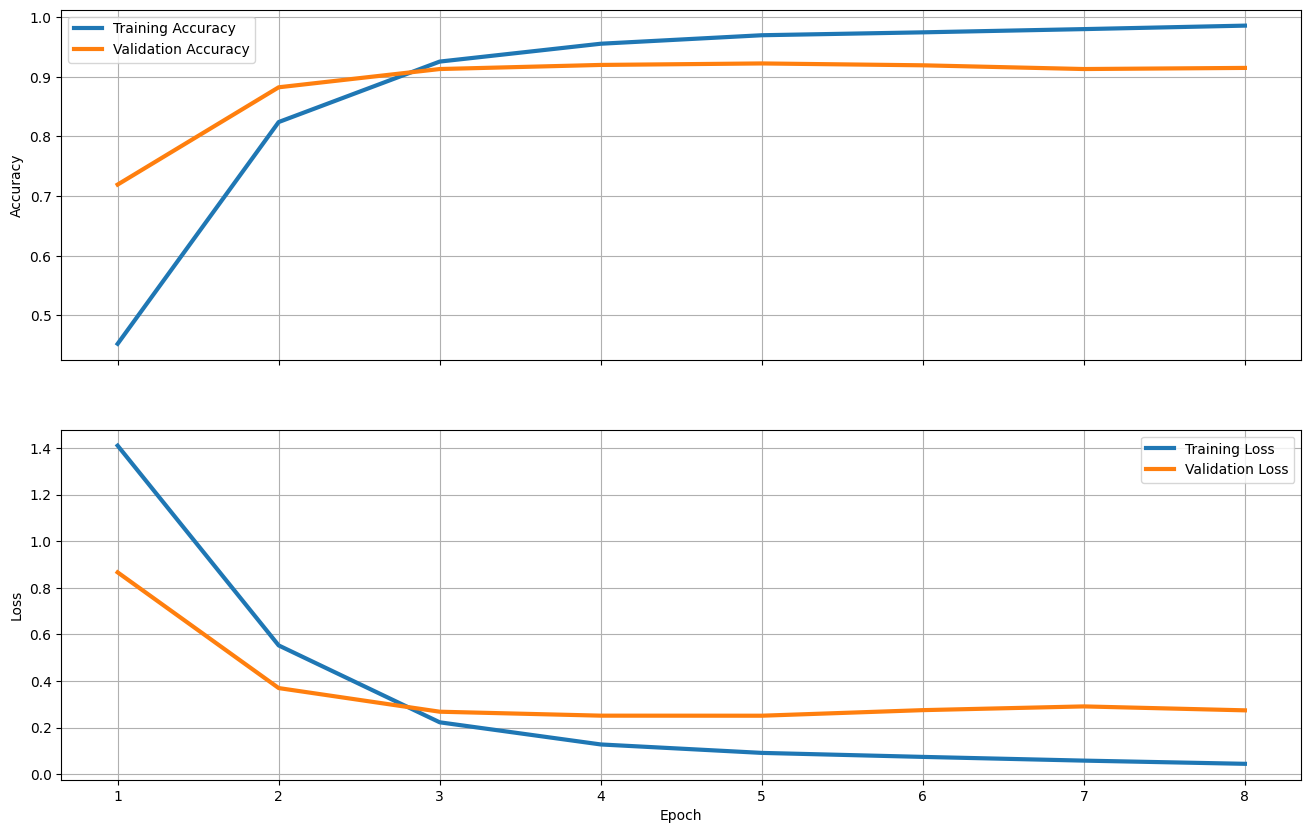

In [ ]:
plot_results(history_lstm)

Compared to the previous experiment, the learning curves are more stable.The model learns very quickly in the first few epochs. After about three epochs, the validation accuracy stops improving while the training accuracy continues to increase. This means that training longer mainly helps the model fit the training data and does not improve performance on unseen data.

In [ ]:
from sklearn.metrics import classification_report

# Predict on test set
y_probs_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = np.argmax(y_probs_lstm, axis=1)

# Classification report
report_lstm = classification_report(
    y_true=y_test_enc,
    y_pred=y_pred_lstm,
    target_names=le.classes_,
    digits=4
)

print(report_lstm)


63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 138ms/step
              precision    recall  f1-score   support

       anger     0.9091    0.9091    0.9091       275
        fear     0.8811    0.8929    0.8869       224
         joy     0.9436    0.9381    0.9408       695
        love     0.7886    0.8679    0.8263       159
     sadness     0.9684    0.9501    0.9592       581
    surprise     0.7419    0.6970    0.7188        66

    accuracy                         0.9190      2000
   macro avg     0.8721    0.8758    0.8735      2000
weighted avg     0.9201    0.9190    0.9193      2000



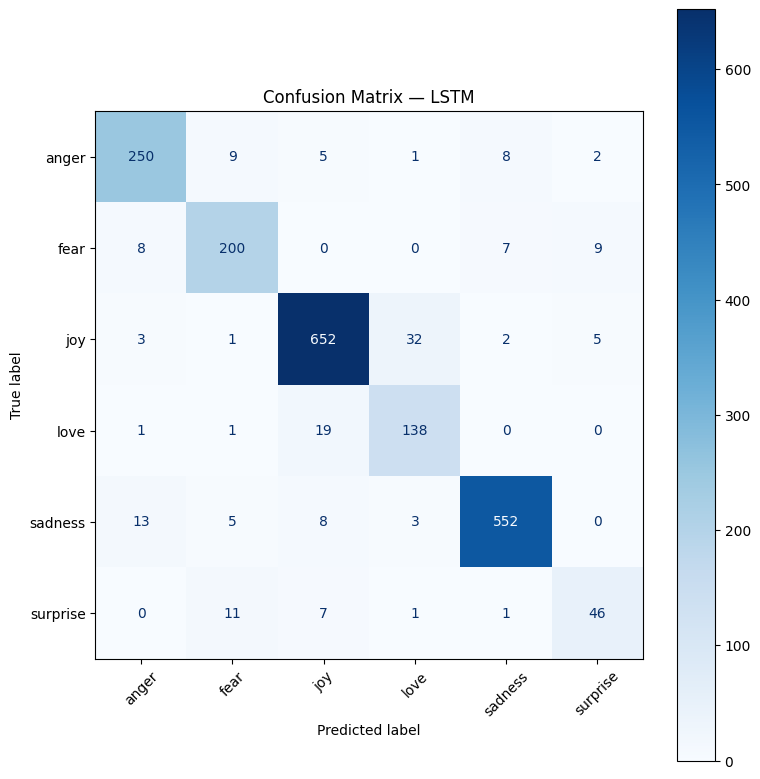

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lstm = confusion_matrix(y_test_enc, y_pred_lstm)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=le.classes_
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

ax.set_title("Confusion Matrix — LSTM")
plt.tight_layout()
plt.show()


The LSTM model shows a clear improvement over the Fully Connected Neural Network by incorporating sequential information and word order into the learning process.Compared to the FCNN, the LSTM reduces confusion between fear and sadness as well as between joy and love, although some overlap remains same. The surprise class still remains the most challenging maybe due to limited data and its strong dependence on contextual cues. Overall, the LSTM provides a meaningful performance gain over non-sequential models, but still falls short of fully capturing nuanced emotional semantics.

## Model 3: Transformer-Based Model

The final approach uses a pretrained transformer model that is fine-tuned for emotion classification. Transformer models leverage contextual embeddings learned from large-scale text corpora, allowing them to capture subtle semantic and emotional patterns in text.

Due to their architecture and pretraining, transformers are expected to outperform traditional neural networks on this task.


In [ ]:
import torch
import numpy as np
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)


In [ ]:
from transformers import AutoTokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Used DistilBERT, a lightweight pretrained Transformer modelto reduce computational cost while maintaining good classification performance

In [ ]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=128
        )
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


In [ ]:
train_dataset = EmotionDataset(X_train, y_train_enc)
test_dataset = EmotionDataset(X_test, y_test_enc)


In [ ]:
# Import and create transformer model for training
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(le.classes_)
)
model.to(device)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    do_eval=True,
    logging_dir="./logs",
    learning_rate=2e-5,
    weight_decay=0.01
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)



model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Due to hardware limitations, the transformer was fine-tuned for one epoch.

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sushmitaabhayrajyadav (sushmitaabhayrajyadav-epita) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss
500,0.766100
1000,0.254100
1500,0.153600
2000,0.154200
2500,0.106200
3000,0.098700


TrainOutput(global_step=3000, training_loss=0.2554977366129557, metrics={'train_runtime': 478.2784, 'train_samples_per_second': 100.36, 'train_steps_per_second': 6.272, 'total_flos': 1080514292544000.0, 'train_loss': 0.2554977366129557, 'epoch': 3.0})

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(test_dataset)
y_pred_best = np.argmax(predictions.predictions, axis=1)

print(classification_report(y_test_enc, y_pred_best, target_names=le.classes_))


              precision    recall  f1-score   support

       anger       0.92      0.92      0.92       275
        fear       0.86      0.91      0.88       224
         joy       0.95      0.94      0.94       695
        love       0.82      0.82      0.82       159
     sadness       0.96      0.96      0.96       581
    surprise       0.80      0.67      0.73        66

    accuracy                           0.92      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.92      0.92      0.92      2000



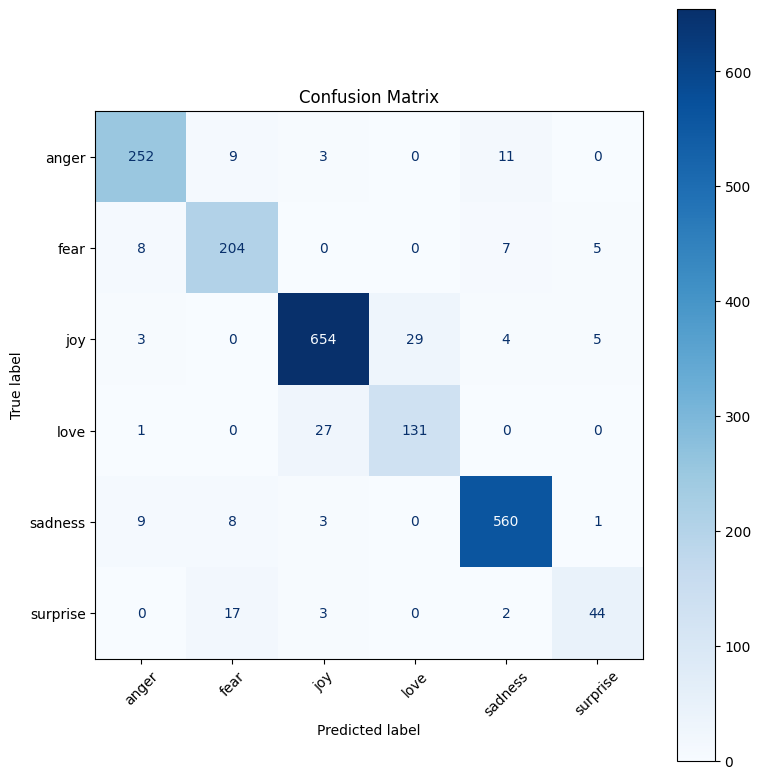

In [ ]:
cm = confusion_matrix(y_true=y_test_enc, y_pred=y_pred_best)

labels = le.classes_
fig, ax = plt.subplots(figsize=(8,8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)
disp.plot(
    ax=ax,
    cmap='Blues',
    xticks_rotation=45,
    values_format='d'
)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

The transformer-based model significantly outperforms both the feedforward and LSTM models. Thanks to pretraining on large-scale corpora, it captures semantic nuances and emotional subtleties that simpler models fail to detect.

This project showed that model choice strongly depends on text representation. While simpler neural networks can achieve decent results with engineered features, sequence-based models and pretrained transformers are far more effective for emotion classification. For future text classification tasks, starting with a pretrained transformer model would be a better choice, especially when emotions depend strongly on context. and focus on data quality and class balance rather than model complexity.